<a href="https://colab.research.google.com/github/samanpython098/Myresearch/blob/main/drift_pipeline_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Detecting Behavioral Drift in AI Coding Agents Through Execution Logs

Colab pipeline: runs table → select tasks → parse trajectories → behavioral metrics → repeated runs per task+agent → baseline → drift → tests → FDR → effect sizes → plots.

Two baseline modes: **reference** (each agent vs a reference agent on the same task) and **sequence** (early vs late runs of the same agent).

Run cells top to bottom; set `DEMO`, `SOURCE`, `MODE` in the last section.

In [ ]:
!pip install -q datasets pyarrow

## Imports

In [1]:
import argparse
import sys
from itertools import combinations
import json
import math
import re
from collections import Counter
from dataclasses import dataclass, field
from pathlib import Path
import numpy as np
import pandas as pd
from scipy import stats
from scipy.spatial.distance import jensenshannon
import matplotlib.pyplot as plt

plt.rcParams['figure.dpi'] = 100

## Configuration

Study design and statistics settings. **Adapt the column names** in `Cfg` to the real AgentLogs schema.

In [2]:
@dataclass
class Cfg:
    # --- schema (ADAPT) ---
    task_id: str = "task_id"
    session_id: str = "run_id"
    model_col: str = "model"          # column identifying the agent/model (mapped to `agents` below)
    log_col: str = "log"              # raw log: messages/events as JSON string, JSONL, or list of dicts
    time_col: str = "created_at"      # run start time (used to order repeated runs in "sequence" mode)
    resolved_col: str = "resolved"    # optional bool/int outcome
    tokens_col: str = "total_tokens"  # optional
    duration_col: str = "duration_s"  # optional fallback if log has no timestamps

    # --- agents ---
    agents: dict = field(default_factory=lambda: {
        "Qwen": r"qwen",
        "CodeLlama": r"code[-_ ]?llama",
        "GPT": r"gpt",
    })

    # --- study design ---
    mode: str = "reference"      # "reference" (agent vs reference agent) or "sequence" (early vs late runs)
    reference_agent: str = "Qwen"  # baseline agent in "reference" mode (must be a key of `agents`)
    min_runs: int = 6            # min repeated executions per (task, agent)
    max_tasks: int = 50          # cap on number of study tasks
    baseline_frac: float = 0.5   # first fraction of runs (by time) = baseline
    min_group: int = 3           # min runs on each side of the split

    # --- statistics ---
    alpha: float = 0.05          # FDR level
    delta_min: float = 0.33      # |Cliff's delta| >= medium effect (Romano et al.)
    jsd_min: float = 0.10        # min Jensen-Shannon distance for tool-usage drift
    n_perm: int = 1000
    seed: int = 42


METRICS = [
    "n_events", "n_tool_calls", "n_read", "n_edit", "n_search", "n_test",
    "n_errors", "error_rate", "retry_rate", "tool_entropy",
    "duration_s", "total_tokens", "resolved",
]
CATEGORIES = ["read", "edit", "search", "test", "shell", "other"]

## 1-2. Load the runs table

Load one table of agent runs (one row per run) from a local file or HuggingFace, and map model strings to agent labels.

In [3]:
def load_runs(source: str, split: str = "train", limit: int = None) -> pd.DataFrame:
    """Local .parquet/.csv/.jsonl file (or a dir holding one runs file) or a HuggingFace dataset id."""
    p = Path(source)
    if p.is_dir():
        files = [f for ext in (".parquet", ".csv", ".jsonl") for f in sorted(p.glob(f"*{ext}"))]
        if not files:
            raise FileNotFoundError(f"no .parquet/.csv/.jsonl in {p}")
        p = files[0]
    if p.is_file():
        df = (pd.read_parquet(p) if p.suffix == ".parquet" else
              pd.read_csv(p) if p.suffix == ".csv" else pd.read_json(p, lines=True))
        return df.head(limit) if limit else df
    from datasets import load_dataset  # lazy import: only for HF sources
    ds = load_dataset(source, split=split, streaming=bool(limit))
    return pd.DataFrame(list(ds.take(limit))) if limit else ds.to_pandas()


def assign_agent(df: pd.DataFrame, cfg: Cfg) -> pd.DataFrame:
    def f(m):
        for agent, pat in cfg.agents.items():
            if re.search(pat, str(m), flags=re.I):
                return agent
        return None
    df = df.copy()
    df["agent"] = df[cfg.model_col].map(f)
    return df.dropna(subset=["agent"])

## 3-4. Select study tasks

Keep tasks with enough repeated runs (all agents in `sequence` mode; reference + at least one other agent in `reference` mode).

In [4]:
def select_study_tasks(sessions, cfg: Cfg):
    """Keep tasks with enough repeated runs: every agent (sequence) or reference + >=1 other (reference)."""
    counts = sessions.groupby([cfg.task_id, "agent"]).size().unstack(fill_value=0)
    counts = counts.reindex(columns=list(cfg.agents), fill_value=0)
    if cfg.mode == "reference":
        ref_ok = counts[cfg.reference_agent] >= cfg.min_runs
        oth_ok = (counts.drop(columns=cfg.reference_agent) >= cfg.min_runs).any(axis=1)
        ok = counts[ref_ok & oth_ok]
    else:
        ok = counts[(counts >= cfg.min_runs).all(axis=1)]
    ids = ok.index.to_numpy()
    rng = np.random.default_rng(cfg.seed)
    if len(ids) > cfg.max_tasks:
        ids = rng.choice(ids, cfg.max_tasks, replace=False)
    study = sessions[sessions[cfg.task_id].isin(ids)].copy()
    print(f"[select] mode={cfg.mode}: {len(ids)} study tasks, {len(study)} runs")
    return study

## 5. Parse log events (trajectory messages -> normalized events)

Parse raw trajectories (OpenAI/OpenHands-style chat messages with `tool_calls`, or flat event dicts) into normalized events. **Adapt `normalize_events`** if your keys differ.

In [5]:
def parse_log(raw) -> list:
    if raw is None or (isinstance(raw, float) and math.isnan(raw)):
        return []
    if isinstance(raw, bytes):
        raw = raw.decode("utf-8", "ignore")
    if isinstance(raw, str):
        s = raw.strip()
        if not s:
            return []
        try:
            obj = json.loads(s)
            raw = obj if isinstance(obj, list) else next(
                (obj[k] for k in ("events", "messages", "history", "trajectory") if isinstance(obj.get(k), list)), [obj])
        except json.JSONDecodeError:
            raw = []
            for line in s.splitlines():
                try:
                    raw.append(json.loads(line))
                except json.JSONDecodeError:
                    continue
    return [e for e in raw if isinstance(e, dict)]


_CAT_PATTERNS = [
    ("test", r"pytest|unittest|tox|run_tests|\btest"),
    ("edit", r"edit|write|patch|replace|create|apply|sed -i"),
    ("search", r"grep|find|search|\brg\b|\bls\b"),
    ("read", r"read|view|open|\bcat\b|\bhead\b|\btail\b"),
    ("shell", r"bash|shell|exec|\brun\b|cmd"),
]
_ERR_RE = re.compile(r"traceback|error|exception|failed|not found", re.I)
_OBS_TYPES = {"observation", "tool_result", "result", "output", "tool_output"}


def _mk(is_call, tool=None, args="", err=False, ts=None):
    cat = "other"
    if is_call:
        probe = f"{tool} {args}".lower()
        cat = next((c for c, pat in _CAT_PATTERNS if re.search(pat, probe)), "other")
    return dict(is_call=is_call, tool=str(tool) if tool else None, sig=(str(tool), args[:200]),
                category=cat, is_error=bool(err), ts=ts)


def normalize_events(e: dict) -> list:
    """Map one raw log record to >=1 normalized events. Handles OpenAI/OpenHands-style chat messages
    (assistant `tool_calls`, `role: tool` results) and flat event dicts. ADAPT keys here if needed."""
    ts = pd.to_datetime(e.get("timestamp") or e.get("time") or e.get("created_at"), errors="coerce", utc=True)
    role = str(e.get("role") or "").lower()
    etype = str(e.get("type") or e.get("event") or "").lower()
    msg = e.get("message") if isinstance(e.get("message"), dict) else {}

    tcs = e.get("tool_calls") or msg.get("tool_calls") or []
    if tcs:                                              # assistant message with one or more tool calls
        out = []
        for tc in tcs:
            if not isinstance(tc, dict):
                continue
            fn = tc.get("function") if isinstance(tc.get("function"), dict) else tc
            args = fn.get("arguments") or fn.get("function_arguments") or ""
            out.append(_mk(True, fn.get("name") or fn.get("function_name"),
                           args if isinstance(args, str) else json.dumps(args), False, ts))
        return out

    text = str(e.get("output") or e.get("observation") or e.get("content") or "")
    code = e.get("exit_code", e.get("returncode"))
    err = bool(e.get("error")) or (code not in (None, 0, "0"))
    if role == "tool" or etype in _OBS_TYPES:            # tool result / observation
        return [_mk(False, err=err or bool(_ERR_RE.search(text[:2000])), ts=ts)]

    tool = e.get("tool") or e.get("tool_name") or e.get("name")
    if tool is None and isinstance(e.get("action"), str):
        tool = e["action"]
    if tool is not None:                                 # flat tool-call event
        return [_mk(True, tool, str(e.get("command") or e.get("args") or e.get("input") or ""), err, ts)]
    return [_mk(False, err=err, ts=ts)]                  # plain message (thinking, final answer, ...)

## 6. Behavioral metrics per session

Extract behavioral metrics per session (steps, tool mix, errors, retries, entropy, duration, outcome).

In [6]:
def session_metrics(raw_log, row, cfg: Cfg) -> dict:
    ev = [x for e in parse_log(raw_log) for x in normalize_events(e)]
    calls = [e for e in ev if e["is_call"]]
    n_calls = len(calls)
    cat_counts = Counter(e["category"] for e in calls)
    tool_counts = Counter(e["tool"] for e in calls)

    probs = np.array(list(tool_counts.values()), float)
    entropy = float(-(probs / probs.sum() * np.log2(probs / probs.sum())).sum()) if n_calls else 0.0
    retries = sum(1 for a, b in zip(calls, calls[1:]) if a["sig"] == b["sig"])
    n_err = sum(e["is_error"] for e in ev)

    ts = [e["ts"] for e in ev if pd.notna(e["ts"])]
    if len(ts) >= 2:
        duration = (max(ts) - min(ts)).total_seconds()
    else:
        duration = row.get(cfg.duration_col, np.nan)

    out = dict(
        n_events=len(ev), n_tool_calls=n_calls,
        n_errors=n_err, error_rate=n_err / max(len(ev), 1),
        retry_rate=retries / max(n_calls, 1), tool_entropy=entropy,
        duration_s=duration,
        total_tokens=row.get(cfg.tokens_col, np.nan),
        resolved=float(row[cfg.resolved_col]) if cfg.resolved_col in row and pd.notna(row[cfg.resolved_col]) else np.nan,
    )
    for c in CATEGORIES:
        out[f"n_{c}"] = cat_counts.get(c, 0)
    return out


def build_metrics_table(sessions: pd.DataFrame, cfg: Cfg) -> pd.DataFrame:
    rows = []
    for _, r in sessions.iterrows():
        m = session_metrics(r[cfg.log_col], r, cfg)
        m.update(task_id=r[cfg.task_id], session_id=r[cfg.session_id],
                 agent=r["agent"], run_ts=pd.to_datetime(r.get(cfg.time_col), errors="coerce", utc=True))
        rows.append(m)
    df = pd.DataFrame(rows)
    print(f"[metrics] {len(df)} sessions parsed")
    return df

## 7-9. Repeated executions, baseline, drift

Baseline vs monitored runs per task (reference agent vs others, or early vs late runs). Compute drift via Mann-Whitney U, Cliff's delta, Cohen's d, and a permutation test on tool-usage Jensen-Shannon distance.

In [7]:
def split_baseline(g: pd.DataFrame, cfg: Cfg):
    """Order runs by time (fall back to row order); first fraction = baseline."""
    g = g.sort_values("run_ts", kind="stable") if g["run_ts"].notna().any() else g
    k = int(round(len(g) * cfg.baseline_frac))
    k = min(max(k, cfg.min_group), len(g) - cfg.min_group)
    if k < cfg.min_group or len(g) - k < cfg.min_group:
        return None, None
    return g.iloc[:k], g.iloc[k:]


def iter_comparisons(metrics: pd.DataFrame, cfg: Cfg):
    """Yield (task, label, baseline_runs, monitored_runs).
    sequence : per (task, agent) early runs vs late runs.
    reference: per task, reference-agent runs vs each other agent's runs."""
    if cfg.mode == "reference":
        for task, g in metrics.groupby("task_id"):
            base = g[g["agent"] == cfg.reference_agent]
            if len(base) < cfg.min_group:
                continue
            for agent, mon in g[g["agent"] != cfg.reference_agent].groupby("agent"):
                if len(mon) >= cfg.min_group:
                    yield task, agent, base, mon
    else:
        for (task, agent), g in metrics.groupby(["task_id", "agent"]):
            base, mon = split_baseline(g, cfg)
            if base is not None:
                yield task, agent, base, mon


def cliffs_delta(x, y):
    """Cliff's delta of x (monitoring) vs y (baseline), via Mann-Whitney U."""
    u, p = stats.mannwhitneyu(x, y, alternative="two-sided", method="auto")
    return 2 * u / (len(x) * len(y)) - 1, p


def cohens_d(x, y):
    nx, ny = len(x), len(y)
    sp = math.sqrt(((nx - 1) * np.var(x, ddof=1) + (ny - 1) * np.var(y, ddof=1)) / (nx + ny - 2))
    return (np.mean(x) - np.mean(y)) / sp if sp > 0 else 0.0


def magnitude(d):
    d = abs(d)
    return "negligible" if d < 0.147 else "small" if d < 0.33 else "medium" if d < 0.474 else "large"


def jsd_permutation(Xb, Xm, n_perm, rng):
    """Jensen-Shannon distance between pooled tool-category usage + permutation p-value."""
    def jsd(a, b):
        pa, pb = a.sum(0), b.sum(0)
        if pa.sum() == 0 or pb.sum() == 0:
            return 0.0
        return float(jensenshannon(pa / pa.sum(), pb / pb.sum(), base=2))
    obs = jsd(Xb, Xm)
    X, nb = np.vstack([Xb, Xm]), len(Xb)
    ge = 0
    for _ in range(n_perm):
        idx = rng.permutation(len(X))
        ge += jsd(X[idx[:nb]], X[idx[nb:]]) >= obs
    return obs, (1 + ge) / (1 + n_perm)


def compute_drift(metrics: pd.DataFrame, cfg: Cfg) -> pd.DataFrame:
    rng = np.random.default_rng(cfg.seed)
    usable = [m for m in METRICS if m in metrics and metrics[m].notna().any()]
    cat_cols = [f"n_{c}" for c in CATEGORIES]
    rows = []
    for task, agent, base, mon in iter_comparisons(metrics, cfg):
        for m in usable:
            b, x = base[m].dropna().to_numpy(float), mon[m].dropna().to_numpy(float)
            if len(b) < cfg.min_group or len(x) < cfg.min_group:
                continue
            bm, xm = np.median(b), np.median(x)
            if np.ptp(np.concatenate([b, x])) == 0:      # constant -> no drift, no test
                delta, d, p = 0.0, 0.0, 1.0
            else:
                delta, p = cliffs_delta(x, b)
                d = cohens_d(x, b)
            rows.append(dict(task_id=task, agent=agent, metric=m, n_base=len(b), n_mon=len(x),
                             base_median=bm, mon_median=xm,
                             rel_change=(xm - bm) / abs(bm) if bm != 0 else np.nan,
                             effect=delta, cohens_d=d, p_value=p, effect_type="cliffs_delta"))
        # distributional drift in tool usage
        jsd, p = jsd_permutation(base[cat_cols].to_numpy(float), mon[cat_cols].to_numpy(float),
                                 cfg.n_perm, rng)
        rows.append(dict(task_id=task, agent=agent, metric="tool_usage_jsd",
                         n_base=len(base), n_mon=len(mon), base_median=np.nan, mon_median=np.nan,
                         rel_change=np.nan, effect=jsd, cohens_d=np.nan, p_value=p,
                         effect_type="jsd"))
    return pd.DataFrame(rows)

## 10-12. FDR correction, effect sizes, drift decision

Benjamini-Hochberg FDR + minimum effect size. Agent-level paired tests are the **primary** inference (per-task tests are underpowered with few runs).

In [8]:
def bh_fdr(p):
    """Benjamini-Hochberg adjusted p-values (q-values)."""
    p = np.asarray(p, float)
    n = len(p)
    order = np.argsort(p)
    ranked = p[order] * n / np.arange(1, n + 1)
    q = np.minimum.accumulate(ranked[::-1])[::-1]
    out = np.empty(n)
    out[order] = np.clip(q, 0, 1)
    return out


def detect_drift(res: pd.DataFrame, cfg: Cfg) -> pd.DataFrame:
    res = res.copy()
    res["q_value"] = bh_fdr(res["p_value"].fillna(1.0))
    is_jsd = res["effect_type"] == "jsd"
    big = np.where(is_jsd, res["effect"] >= cfg.jsd_min, res["effect"].abs() >= cfg.delta_min)
    res["significant"] = res["q_value"] < cfg.alpha
    res["magnitude"] = np.where(is_jsd, np.where(res["effect"] >= cfg.jsd_min, "drift", "negligible"),
                                res["effect"].map(magnitude))
    res["drift"] = res["significant"] & big                       # FDR-controlled (task level)
    res["drift_nominal"] = (res["p_value"] < cfg.alpha) & big     # uncorrected, exploratory
    res["direction"] = np.where(is_jsd, "n/a", np.where(res["effect"] > 0, "increase", "decrease"))
    return res


def summarize(res: pd.DataFrame) -> pd.DataFrame:
    """Task-level summary per agent x metric (exploratory)."""
    return (res.groupby(["agent", "metric"])
               .agg(n_tests=("drift", "size"), n_drift_fdr=("drift", "sum"),
                    n_drift_nominal=("drift_nominal", "sum"),
                    drift_rate=("drift_nominal", "mean"), mean_effect=("effect", "mean"),
                    median_q=("q_value", "median"))
               .reset_index())


def agent_level(res: pd.DataFrame, cfg: Cfg) -> pd.DataFrame:
    """PRIMARY inference. Per-task tests have few runs (min p ~ 0.01), so they cannot survive
    FDR over hundreds of tests. Here each task contributes ONE paired observation
    (baseline median vs monitoring median) and we test across tasks per agent x metric.
      - scalar metrics : Wilcoxon signed-rank, effect = matched-pairs rank-biserial correlation
      - tool-usage JSD : Fisher's combination of per-task permutation p-values, effect = median JSD
    BH-FDR is applied across all agent x metric tests."""
    rows = []
    for (agent, m), g in res.groupby(["agent", "metric"]):
        if m == "tool_usage_jsd":
            p = stats.combine_pvalues(g["p_value"].clip(lower=1e-300), method="fisher")[1]
            eff, etype, rel = g["effect"].median(), "jsd", np.nan
        else:
            g = g.dropna(subset=["base_median", "mon_median"])
            diff = (g["mon_median"] - g["base_median"]).to_numpy(float)
            nz = diff[diff != 0]
            if len(nz) < 5:
                p, eff = 1.0, 0.0
            else:
                p = stats.wilcoxon(nz).pvalue
                ranks = stats.rankdata(np.abs(nz))
                eff = (ranks[nz > 0].sum() - ranks[nz < 0].sum()) / ranks.sum()
            etype, rel = "rank_biserial", g["rel_change"].median()
        rows.append(dict(agent=agent, metric=m, n_tasks=len(g), effect=eff, effect_type=etype,
                         median_rel_change=rel, p_value=p))
    out = pd.DataFrame(rows)
    out["q_value"] = bh_fdr(out["p_value"])
    is_jsd = out["effect_type"] == "jsd"
    big = np.where(is_jsd, out["effect"] >= cfg.jsd_min, out["effect"].abs() >= cfg.delta_min)
    out["drift"] = (out["q_value"] < cfg.alpha) & big
    out["direction"] = np.where(is_jsd, "n/a", np.where(out["effect"] > 0, "increase", "decrease"))
    return out

## 13. Plots

Drift plots: share-of-tasks heatmap, agent-level effect heatmap, volcano plot, baseline-vs-monitoring boxplots.

In [9]:
def _done(fig):
    """Show the figure inline in Colab/Jupyter, otherwise just free it (it is already saved)."""
    if "ipykernel" in sys.modules or "google.colab" in sys.modules:
        plt.show()
    else:
        plt.show()


def _heatmap(pivot, title, fname, outdir, cmap, center=None, fmt="{:.2f}", marks=None, vlim=1.0):
    fig, ax = plt.subplots(figsize=(1 + 0.8 * pivot.shape[1], 1.2 + 0.7 * pivot.shape[0]))
    kw = dict(vmin=-vlim, vmax=vlim) if center == 0 else {}
    if marks is not None:
        marks = marks.fillna(False).astype(bool)
    im = ax.imshow(pivot.values, cmap=cmap, aspect="auto", **kw)
    ax.set_xticks(range(pivot.shape[1]), pivot.columns, rotation=45, ha="right")
    ax.set_yticks(range(pivot.shape[0]), pivot.index)
    for i in range(pivot.shape[0]):
        for j in range(pivot.shape[1]):
            v = pivot.values[i, j]
            if pd.notna(v):
                star = "*" if (marks is not None and marks.values[i, j]) else ""
                dark = center == 0 and abs(v) > 0.6 * vlim
                ax.text(j, i, fmt.format(v) + star, ha="center", va="center", fontsize=8,
                        color="white" if dark else "black")
    ax.set_title(title)
    fig.colorbar(im, ax=ax, shrink=0.8)
    fig.tight_layout()
    fig.savefig(outdir / fname, dpi=200)
    _done(fig)


def make_plots(metrics, res, summ, agg, outdir: Path):
    outdir.mkdir(parents=True, exist_ok=True)
    _heatmap(summ.pivot(index="agent", columns="metric", values="drift_rate"),
             "Share of tasks with drift (uncorrected, exploratory)", "drift_rate_heatmap.png",
             outdir, "Blues")
    a = agg[agg.metric != "tool_usage_jsd"]
    _heatmap(a.pivot(index="agent", columns="metric", values="effect"),
             "Agent-level effect (rank-biserial); * = drift (FDR q<0.05)",
             "agent_effect_heatmap.png", outdir, "RdBu_r", center=0,
             marks=a.pivot(index="agent", columns="metric", values="drift"))

    # volcano-style: effect vs significance
    fig, ax = plt.subplots(figsize=(7, 5))
    r = res[res.effect_type == "cliffs_delta"]
    for agent, g in r.groupby("agent"):
        ax.scatter(g["effect"], -np.log10(g["q_value"].clip(lower=1e-12)), s=12, alpha=0.5, label=agent)
    ax.axhline(-np.log10(0.05), ls="--", c="grey", lw=1)
    for x in (-0.33, 0.33):
        ax.axvline(x, ls="--", c="grey", lw=1)
    ax.set_xlabel("Cliff's delta"); ax.set_ylabel("-log10(q)")
    ax.set_title("Drift tests across tasks, agents and metrics"); ax.legend()
    fig.tight_layout(); fig.savefig(outdir / "volcano.png", dpi=200); _done(fig)

    # baseline vs monitoring distribution of key metrics, per compared agent
    key = [m for m in ("n_tool_calls", "error_rate", "tool_entropy") if m in metrics]
    vals = {}
    for task, agent, base, mon in iter_comparisons(metrics, CFG_GLOBAL):
        for m in key:
            d = vals.setdefault(agent, {}).setdefault(m, ([], []))
            d[0].append(base[m].median()); d[1].append(mon[m].median())
    if vals and key:
        agents = sorted(vals)
        fig, axes = plt.subplots(len(key), len(agents), figsize=(3.2 * len(agents), 2.8 * len(key)),
                                 squeeze=False)
        for j, agent in enumerate(agents):
            for i, m in enumerate(key):
                ax = axes[i][j]
                ax.boxplot(list(vals[agent][m]), tick_labels=["baseline", "monitor"])
                if i == 0: ax.set_title(agent)
                if j == 0: ax.set_ylabel(m)
        ref = f" (baseline = {CFG_GLOBAL.reference_agent})" if CFG_GLOBAL.mode == "reference" else ""
        fig.suptitle("Per-task median: baseline vs monitoring runs" + ref)
        fig.tight_layout(); fig.savefig(outdir / "baseline_vs_monitoring.png", dpi=200); _done(fig)

## 14. Cross-agent comparison (statistics)

Compares **all agents with each other**: descriptive stats, omnibus Friedman test on per-task medians (paired by task, Kendall's W effect size), pairwise Wilcoxon signed-rank with rank-biserial effects, BH-FDR, tool-mix and Jensen-Shannon distance. `summarize_findings` prints a plain-language readout.

In [10]:
def _wilcoxon_p(diff):
    nz = np.asarray(diff, float)
    nz = nz[nz != 0]
    return 1.0 if len(nz) < 5 else float(stats.wilcoxon(nz).pvalue)


def _rank_biserial(diff):
    nz = np.asarray(diff, float)
    nz = nz[nz != 0]
    if len(nz) == 0:
        return 0.0
    r = stats.rankdata(np.abs(nz))
    return float((r[nz > 0].sum() - r[nz < 0].sum()) / r.sum())


def compare_agents(metrics: pd.DataFrame, cfg: Cfg) -> dict:
    """Compare ALL agents with each other (independent of the drift baseline).
    descriptive: per agent x metric run-level n, mean, sd, median, IQR.
    omnibus    : Friedman test across agents on per-task medians (paired by task) + Kendall's W
                 (Wilcoxon signed-rank when only 2 agents), BH-FDR across metrics.
    pairwise   : Wilcoxon signed-rank for every agent pair x metric on per-task medians,
                 effect = matched-pairs rank-biserial (positive => agent_a higher), BH-FDR across all.
    tool_mix / jsd: tool-category usage proportions and pairwise Jensen-Shannon distance."""
    usable = [m for m in METRICS if m in metrics and metrics[m].notna().any()]

    d = []
    for agent, g in metrics.groupby("agent"):
        for m in usable:
            x = g[m].dropna()
            if len(x):
                d.append(dict(agent=agent, metric=m, n_runs=len(x), mean=x.mean(), sd=x.std(),
                              median=x.median(), q1=x.quantile(.25), q3=x.quantile(.75)))
    descr = pd.DataFrame(d)

    med = metrics.groupby(["task_id", "agent"])[usable].median().reset_index()
    om, pw = [], []
    for m in usable:
        w = med.pivot(index="task_id", columns="agent", values=m).dropna()
        agents, k = list(w.columns), w.shape[1]
        if len(w) < 5 or k < 2:
            continue
        const = np.ptp(w.to_numpy(float)) == 0
        if k >= 3 and not const:
            stat, p = stats.friedmanchisquare(*[w[a].to_numpy(float) for a in agents])
            kw_, test = stat / (len(w) * (k - 1)), "Friedman"
        elif k == 2:
            stat, p, kw_, test = np.nan, _wilcoxon_p(w[agents[0]] - w[agents[1]]), np.nan, "Wilcoxon"
        else:
            stat, p, kw_, test = np.nan, 1.0, 0.0, "Friedman"
        om.append(dict(metric=m, k_agents=k, n_tasks=len(w), test=test, statistic=stat,
                       p_value=float(p), kendall_w=kw_,
                       highest=w.median().idxmax(), lowest=w.median().idxmin()))
        for a, b in combinations(agents, 2):
            diff = (w[a] - w[b]).to_numpy(float)
            pw.append(dict(metric=m, agent_a=a, agent_b=b, n_tasks=len(w),
                           median_a=w[a].median(), median_b=w[b].median(),
                           median_diff=float(np.median(diff)), effect=_rank_biserial(diff),
                           p_value=_wilcoxon_p(diff)))
    om, pw = pd.DataFrame(om), pd.DataFrame(pw)
    if len(om):
        om["q_value"] = bh_fdr(om["p_value"])
        om["significant"] = om["q_value"] < cfg.alpha
    if len(pw):
        pw["q_value"] = bh_fdr(pw["p_value"])
        pw["significant"] = (pw["q_value"] < cfg.alpha) & (pw["effect"].abs() >= cfg.delta_min)
        pw["magnitude"] = pw["effect"].map(magnitude)

    cat_cols = [f"n_{c}" for c in CATEGORIES]
    tot = metrics.groupby("agent")[cat_cols].sum()
    prop = tot.div(tot.sum(axis=1).replace(0, np.nan), axis=0).fillna(0)
    ag = list(prop.index)
    jsd = pd.DataFrame([[float(jensenshannon(prop.loc[a], prop.loc[b], base=2)) if a != b else 0.0
                         for b in ag] for a in ag], index=ag, columns=ag).fillna(0.0)
    return dict(descriptive=descr, omnibus=om, pairwise=pw, tool_mix=prop, jsd=jsd, task_medians=med)


def summarize_findings(cmp: dict, max_lines: int = 20):
    """Plain-language readout of the cross-agent statistics."""
    om, pw = cmp["omnibus"], cmp["pairwise"]
    if not len(om):
        print("Not enough tasks with all agents for cross-agent tests.")
        return
    sig = om[om["significant"]].sort_values("q_value")
    print(f"{len(sig)}/{len(om)} metrics differ across agents (omnibus, FDR q<0.05).\n")
    for _, r in sig.head(max_lines).iterrows():
        pairs = pw[(pw.metric == r.metric) & pw.significant]
        txt = "; ".join(
            f"{(x.agent_a if x.effect > 0 else x.agent_b)} > {(x.agent_b if x.effect > 0 else x.agent_a)} "
            f"(r={abs(x.effect):.2f}, {x.magnitude})" for x in pairs.itertuples())
        w = f", W={r.kendall_w:.2f}" if pd.notna(r.kendall_w) else ""
        print(f"- {r.metric}: highest={r.highest}, lowest={r.lowest} (q={r.q_value:.3g}{w})"
              + (f" | significant pairs: {txt}" if txt else ""))

## 15. Cross-agent plots

Per-metric boxplots with task-level points, behavioural-profile heatmap, pairwise effect-size heatmap with significance stars, tool-mix bars, agent-to-agent tool-usage distance, and metric trajectories over repeated runs.

In [11]:
def make_agent_plots(metrics: pd.DataFrame, cmp: dict, outdir: Path):
    outdir.mkdir(parents=True, exist_ok=True)
    om, pw, med = cmp["omnibus"], cmp["pairwise"], cmp["task_medians"]
    if not len(om):
        print("Not enough tasks with all agents for cross-agent plots.")
        return
    agents = sorted(metrics["agent"].unique())
    colors = {a: plt.cm.tab10(i % 10) for i, a in enumerate(agents)}
    rng = np.random.default_rng(0)

    # 1) distribution of per-task medians, per metric, per agent
    ms = list(om.metric)
    ncols = min(4, len(ms))
    nrows = math.ceil(len(ms) / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(3.4 * ncols, 3.0 * nrows), squeeze=False)
    for ax in axes.ravel()[len(ms):]:
        ax.axis("off")
    for ax, m in zip(axes.ravel(), ms):
        data = [med.loc[med.agent == a, m].dropna().to_numpy() for a in agents]
        bp = ax.boxplot(data, tick_labels=agents, showfliers=False, patch_artist=True)
        for patch, a in zip(bp["boxes"], agents):
            patch.set_facecolor(colors[a]); patch.set_alpha(0.35)
        for i, (a, y) in enumerate(zip(agents, data), start=1):
            ax.scatter(rng.normal(i, 0.06, len(y)), y, s=8, color=colors[a], alpha=0.6)
        r = om[om.metric == m].iloc[0]
        ax.set_title(f"{m}\nq={r.q_value:.2g}" + (" *" if r.significant else ""), fontsize=9)
        ax.tick_params(axis="x", labelrotation=20, labelsize=8)
    fig.suptitle("Per-task medians by agent (* = agents differ, omnibus FDR q<0.05)")
    fig.tight_layout(); fig.savefig(outdir / "agents_boxplots.png", dpi=200); _done(fig)

    # 2) behavioural profile: z-score of each metric across agents
    prof = med.groupby("agent")[ms].mean()
    z = ((prof - prof.mean()) / prof.std(ddof=0).replace(0, np.nan)).fillna(0)
    _heatmap(z, "Behavioural profile (z-score across agents, per-task medians)",
             "agents_profile_heatmap.png", outdir, "RdBu_r", center=0, vlim=1.5)

    # 3) pairwise effect sizes with significance stars
    if len(pw):
        pw = pw.assign(pair=pw.agent_a + " vs " + pw.agent_b)
        _heatmap(pw.pivot(index="pair", columns="metric", values="effect"),
                 "Pairwise effect (rank-biserial, + => first agent higher); * = FDR q<0.05 & |r|>=0.33",
                 "agents_pairwise_effects.png", outdir, "RdBu_r", center=0,
                 marks=pw.pivot(index="pair", columns="metric", values="significant"))

    # 4) tool-category mix
    mix = cmp["tool_mix"].reindex(agents)
    fig, ax = plt.subplots(figsize=(1.6 * len(agents) + 3, 3.8))
    bottom = np.zeros(len(agents))
    for c in mix.columns:
        ax.bar(agents, mix[c].to_numpy(), bottom=bottom, label=c.replace("n_", ""))
        bottom += mix[c].to_numpy()
    ax.set_ylabel("share of tool calls"); ax.set_title("Tool-category usage by agent")
    ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
    fig.tight_layout(); fig.savefig(outdir / "agents_tool_mix.png", dpi=200); _done(fig)

    # 5) tool-usage distance between agents
    _heatmap(cmp["jsd"].reindex(index=agents, columns=agents),
             "Tool-usage distance between agents (Jensen-Shannon)", "agents_jsd.png", outdir, "Blues")

    # 6) metric trajectories over repeated runs (run order within task+agent)
    m2 = metrics.copy()
    if m2["run_ts"].notna().any():
        m2 = m2.sort_values("run_ts", kind="stable")
    m2["run_idx"] = m2.groupby(["task_id", "agent"]).cumcount()
    key = [m for m in ("n_tool_calls", "error_rate", "tool_entropy", "resolved") if m in ms]
    if key:
        fig, axes = plt.subplots(1, len(key), figsize=(3.8 * len(key), 3.2), squeeze=False)
        for ax, m in zip(axes[0], key):
            for a in agents:
                g = m2[m2.agent == a].groupby("run_idx")[m].agg(["mean", "sem"]).fillna(0)
                ax.plot(g.index, g["mean"], marker="o", ms=3, color=colors[a], label=a)
                ax.fill_between(g.index, g["mean"] - g["sem"], g["mean"] + g["sem"],
                                color=colors[a], alpha=0.15)
            ax.set_xlabel("run order within task"); ax.set_title(m, fontsize=9)
        axes[0][0].legend(fontsize=8)
        fig.suptitle("Behaviour across repeated runs (mean ± SEM over runs)")
        fig.tight_layout(); fig.savefig(outdir / "agents_run_trajectories.png", dpi=200); _done(fig)

## Demo data (synthetic) -- for testing the pipeline end to end

Synthetic data with injected drift in Qwen, to sanity-check the pipeline.

In [12]:
def make_demo(cfg: Cfg, n_tasks=20, n_runs=10, seed=0):
    """Synthetic runs table with OpenAI-style message logs.
    Injected effects: Qwen degrades in its later runs (sequence mode);
    GPT is bash-heavy with extra steps (reference mode vs Qwen)."""
    rng = np.random.default_rng(seed)
    tools = ["read_file", "edit_file", "grep_search", "run_tests", "bash"]
    models = {"Qwen": "qwen2.5-coder", "CodeLlama": "CodeLlama-34b", "GPT": "gpt-4o"}
    rows = []
    for t in range(n_tasks):
        for agent, model in models.items():
            for r in range(n_runs):
                degraded = agent == "Qwen" and r >= n_runs // 2
                bashy = agent == "GPT"
                p_err = 0.45 if degraded else 0.15
                n_steps = int(rng.integers(10, 25)) + (15 if degraded else 0) + (8 if bashy else 0)
                probs = [.1, .1, .1, .1, .6] if (degraded or bashy) else [.3, .2, .2, .15, .15]
                ts0 = pd.Timestamp("2026-01-01", tz="UTC") + pd.Timedelta(days=r)
                msgs = [{"role": "user", "content": "Fix the issue", "timestamp": ts0.isoformat()}]
                for k in range(n_steps):
                    ts = (ts0 + pd.Timedelta(seconds=5 * k)).isoformat()
                    tool = str(rng.choice(tools, p=probs))
                    msgs.append({"role": "assistant", "content": "", "timestamp": ts, "tool_calls": [
                        {"id": f"c{k}", "type": "function", "function": {
                            "name": tool, "arguments": json.dumps({"command": f"{tool} {int(rng.integers(3))}"})}}]})
                    bad = rng.random() < p_err
                    msgs.append({"role": "tool", "tool_call_id": f"c{k}", "timestamp": ts,
                                 "content": "Traceback: error" if bad else "ok"})
                rows.append({cfg.session_id: f"t{t}-{agent}-{r}", cfg.task_id: f"t{t}", cfg.model_col: model,
                             cfg.time_col: ts0, cfg.resolved_col: int(rng.random() < 0.4),
                             cfg.log_col: json.dumps(msgs)})
    return pd.DataFrame(rows)

## Pipeline runner

`run()` chains every stage: select → parse → metrics → drift → tests → FDR → plots.

In [13]:
CFG_GLOBAL = Cfg()


def run(cfg: Cfg, runs: pd.DataFrame, out: Path, plots: bool = True):
    """Full pipeline on a runs table (one row per agent run).
    Returns (metrics, task_level, summary, agent_level, cross_agent). plots=False skips figures."""
    global CFG_GLOBAL
    CFG_GLOBAL = cfg
    out.mkdir(parents=True, exist_ok=True)
    if cfg.mode == "reference" and cfg.reference_agent not in cfg.agents:
        raise ValueError(f"reference_agent {cfg.reference_agent!r} must be a key of cfg.agents")

    runs = assign_agent(runs, cfg)                      # map model strings -> agent labels
    runs = select_study_tasks(runs, cfg)                # tasks with enough repeated runs
    metrics = build_metrics_table(runs, cfg)            # parse log events -> behavioral metrics
    metrics.to_csv(out / "run_metrics.csv", index=False)

    raw = compute_drift(metrics, cfg)                   # baseline vs monitored runs, tests, effect sizes
    res = detect_drift(raw, cfg)                        # FDR + decision (task level, exploratory)
    summ = summarize(res)
    agg = agent_level(res, cfg)                         # primary inference, FDR across agent x metric
    res.to_csv(out / "drift_task_level.csv", index=False)
    summ.to_csv(out / "drift_task_summary.csv", index=False)
    agg.to_csv(out / "drift_agent_level.csv", index=False)
    cmp = compare_agents(metrics, cfg)                  # cross-agent statistics (all agents vs each other)
    for k in ("descriptive", "omnibus", "pairwise"):
        cmp[k].to_csv(out / f"agents_{k}.csv", index=False)
    if plots:
        make_plots(metrics, res, summ, agg, out / "plots")
        make_agent_plots(metrics, cmp, out / "plots")

    print("\n=== Cross-agent differences ===")
    summarize_findings(cmp)
    print("\n=== Agent-level drift (FDR q<%.2f) ===" % cfg.alpha)
    print(agg[agg.drift].round(4).to_string(index=False) if agg.drift.any() else "none detected")
    print(f"\nTask-level tests: {len(res)} | FDR-significant: {int(res['drift'].sum())} | "
          f"nominal: {int(res['drift_nominal'].sum())} | results in {out}/")
    return metrics, res, summ, agg, cmp


def _in_notebook() -> bool:
    return "ipykernel" in sys.modules or "google.colab" in sys.modules

## Prepare your runs table

One row per agent run. Required columns (names configurable in `Cfg`): `task_id`, `run_id`, `model` (string, mapped via `cfg.agents`), `log` (the trajectory: list of messages/events or a JSON string). Optional: `created_at`, `resolved`, `total_tokens`, `duration_s`.

```python
runs = pd.DataFrame({"task_id": ..., "run_id": ..., "model": ..., "log": ..., "resolved": ...})
runs.to_parquet("runs.parquet")
```

For a public trajectory dataset, flatten it into this shape first (check its columns with `load_runs(...).columns`). Version/condition comparisons: encode them in the model string (e.g. `gpt-4o@v1`, `gpt-4o@v2`) and add matching patterns to `cfg.agents`.

## Run the pipeline

`DEMO = True` runs on synthetic data. For real data set `DEMO = False` and `SOURCE` to a file, folder, or HuggingFace dataset id. For Google Drive: `from google.colab import drive; drive.mount('/content/drive')`.

This cell computes everything and writes CSVs; the figures and tables below are shown in separate cells.

In [14]:
DEMO   = True                          # True -> synthetic data
SOURCE = "/content/runs.parquet"       # used when DEMO = False
MODE   = "reference"                   # "reference" (agents vs reference agent) or "sequence" (early vs late runs)
REFERENCE_AGENT = "Qwen"               # baseline agent in reference mode
OUT    = Path("drift_results")

cfg = Cfg()
cfg.mode, cfg.reference_agent = MODE, REFERENCE_AGENT
# cfg.agents = {"Qwen": r"qwen", "CodeLlama": r"code[-_ ]?llama", "GPT": r"gpt"}   # model-string patterns
# cfg.min_runs = 6; cfg.max_tasks = 50; cfg.baseline_frac = 0.5

runs = make_demo(cfg) if DEMO else load_runs(SOURCE)
metrics, res, summ, agg, cmp = run(cfg, runs, OUT, plots=False)

[select] mode=reference: 20 study tasks, 600 runs
[metrics] 600 sessions parsed

=== Cross-agent differences ===
10/12 metrics differ across agents (omnibus, FDR q<0.05).

- tool_entropy: highest=CodeLlama, lowest=GPT (q=2.47e-08, W=1.00) | significant pairs: CodeLlama > GPT (r=1.00, large); CodeLlama > Qwen (r=1.00, large); Qwen > GPT (r=1.00, large)
- n_errors: highest=Qwen, lowest=CodeLlama (q=4.69e-08, W=0.93) | significant pairs: GPT > CodeLlama (r=0.89, large); Qwen > CodeLlama (r=1.00, large); Qwen > GPT (r=1.00, large)
- n_read: highest=CodeLlama, lowest=GPT (q=1.21e-07, W=0.87) | significant pairs: CodeLlama > GPT (r=1.00, large); CodeLlama > Qwen (r=0.97, large); Qwen > GPT (r=0.86, large)
- n_tool_calls: highest=GPT, lowest=CodeLlama (q=4.99e-07, W=0.75) | significant pairs: GPT > CodeLlama (r=1.00, large); Qwen > CodeLlama (r=1.00, large)
- error_rate: highest=Qwen, lowest=GPT (q=4.99e-07, W=0.75) | significant pairs: Qwen > CodeLlama (r=1.00, large); Qwen > GPT (r=1.00, la

# A. Drift results (each agent vs baseline)

### Agent-level drift table (primary result)
`drift = True` means FDR q < 0.05 **and** a large enough effect. `effect` is the rank-biserial correlation (or JSD for tool usage).

In [15]:
agg.sort_values(['drift','q_value'], ascending=[False, True]).round(4)

,agent,metric,n_tasks,effect,effect_type,median_rel_change,p_value,q_value,drift,direction
12,CodeLlama,tool_usage_jsd,20,0.2751,jsd,NaN,0.0000,0.0000,True,n/a
25,GPT,tool_usage_jsd,20,0.1413,jsd,NaN,0.0000,0.0000,True,n/a
1,CodeLlama,error_rate,20,-1.0000,rank_biserial,-0.4929,0.0000,0.0000,True,decrease
11,CodeLlama,tool_entropy,20,1.0000,rank_biserial,0.1134,0.0000,0.0000,True,increase
14,GPT,error_rate,20,-1.0000,rank_biserial,-0.4963,0.0000,0.0000,True,decrease
24,GPT,tool_entropy,20,-1.0000,rank_biserial,-0.1019,0.0000,0.0000,True,decrease
10,CodeLlama,retry_rate,20,-0.9143,rank_biserial,-0.4343,0.0001,0.0002,True,decrease
3,CodeLlama,n_errors,20,-1.0000,rank_biserial,-0.6182,0.0001,0.0002,True,decrease
16,GPT,n_errors,20,-1.0000,rank_biserial,-0.4833,0.0001,0.0002,True,decrease
0,CodeLlama,duration_s,20,-1.0000,rank_biserial,-0.3226,0.0001,0.0003,True,decrease


### Drift plots

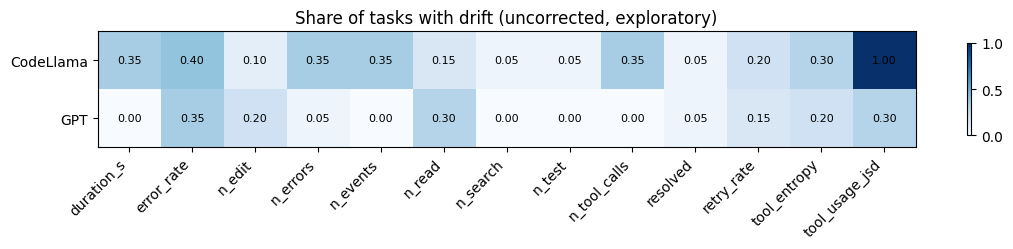

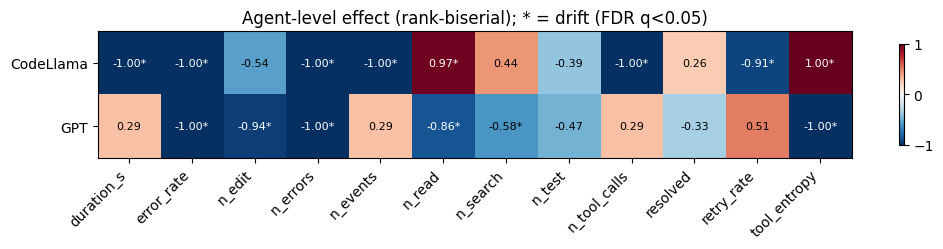

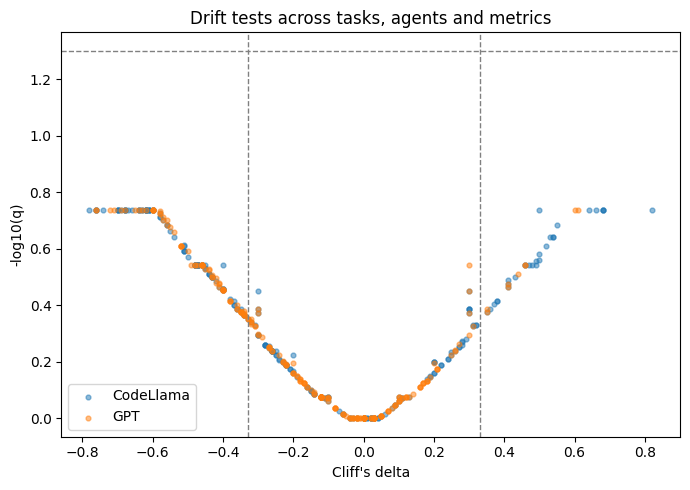

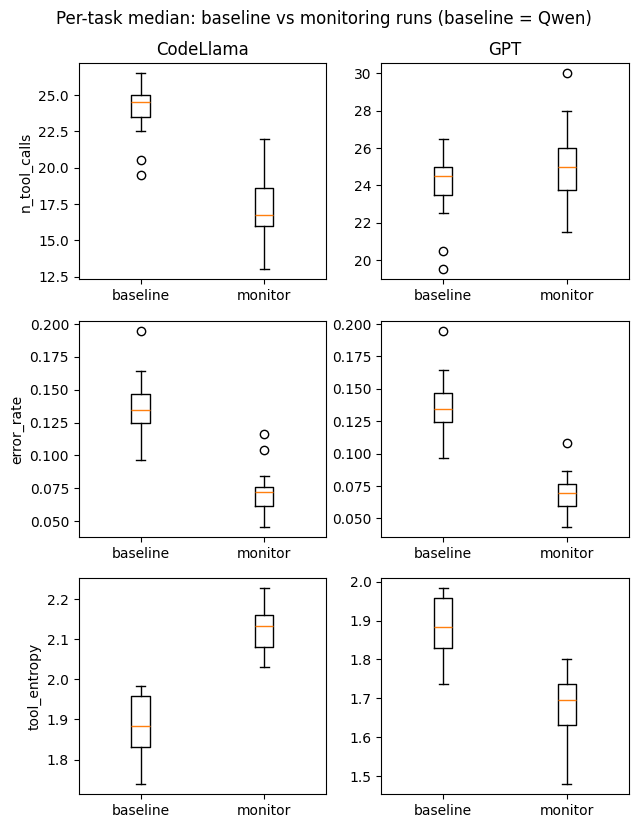

In [16]:
make_plots(metrics, res, summ, agg, OUT / 'plots')

# B. Comparison among agents (statistics)

### Plain-language readout

In [17]:
summarize_findings(cmp)

10/12 metrics differ across agents (omnibus, FDR q<0.05).

- tool_entropy: highest=CodeLlama, lowest=GPT (q=2.47e-08, W=1.00) | significant pairs: CodeLlama > GPT (r=1.00, large); CodeLlama > Qwen (r=1.00, large); Qwen > GPT (r=1.00, large)
- n_errors: highest=Qwen, lowest=CodeLlama (q=4.69e-08, W=0.93) | significant pairs: GPT > CodeLlama (r=0.89, large); Qwen > CodeLlama (r=1.00, large); Qwen > GPT (r=1.00, large)
- n_read: highest=CodeLlama, lowest=GPT (q=1.21e-07, W=0.87) | significant pairs: CodeLlama > GPT (r=1.00, large); CodeLlama > Qwen (r=0.97, large); Qwen > GPT (r=0.86, large)
- n_tool_calls: highest=GPT, lowest=CodeLlama (q=4.99e-07, W=0.75) | significant pairs: GPT > CodeLlama (r=1.00, large); Qwen > CodeLlama (r=1.00, large)
- error_rate: highest=Qwen, lowest=GPT (q=4.99e-07, W=0.75) | significant pairs: Qwen > CodeLlama (r=1.00, large); Qwen > GPT (r=1.00, large)
- n_events: highest=GPT, lowest=CodeLlama (q=4.99e-07, W=0.75) | significant pairs: GPT > CodeLlama (r=1.00,

### Descriptive statistics (median and IQR over runs)

In [18]:
d = cmp["descriptive"].copy()
d["median [IQR]"] = d.apply(lambda r: f"{r['median']:.3g} [{r['q1']:.3g}, {r['q3']:.3g}]", axis=1)
d.pivot(index="metric", columns="agent", values="median [IQR]")

agent,CodeLlama,GPT,Qwen
metric,,,
duration_s,"80 [60, 96.2]","120 [100, 135]","118 [70, 150]"
error_rate,"0.0715 [0.0426, 0.102]","0.0702 [0.0488, 0.0934]","0.13 [0.0696, 0.21]"
n_edit,"3 [2, 4]","2 [1, 3]","4 [2, 5]"
n_errors,"2 [1, 4]","4 [2, 5]","6 [2, 14]"
n_events,"35 [27, 41.5]","51 [43, 57]","50 [31, 63]"
n_read,"5 [3.75, 6]","2 [1, 4]","3 [2, 5]"
n_search,"3 [2, 4]","3 [1, 4]","3 [2, 4]"
n_test,"2 [2, 3]","2 [1.75, 3]","3 [2, 4]"
n_tool_calls,"17 [13, 20.2]","25 [21, 28]","24.5 [15, 31]"


### Omnibus test: do the agents differ? (Friedman on per-task medians, FDR across metrics)
`kendall_w` is the effect size: 0 = the agents' ranking varies randomly across tasks, 1 = the agents are ranked the same way in every task.

In [19]:
cmp['omnibus'].sort_values('q_value').round(4)

,metric,k_agents,n_tasks,test,statistic,p_value,kendall_w,highest,lowest,q_value,significant
9,tool_entropy,3,20,Friedman,40.0000,0.0000,1.0000,CodeLlama,GPT,0.0000,True
6,n_errors,3,20,Friedman,37.3333,0.0000,0.9333,Qwen,CodeLlama,0.0000,True
2,n_read,3,20,Friedman,34.6234,0.0000,0.8656,CodeLlama,GPT,0.0000,True
1,n_tool_calls,3,20,Friedman,30.1558,0.0000,0.7539,GPT,CodeLlama,0.0000,True
7,error_rate,3,20,Friedman,30.1000,0.0000,0.7525,Qwen,GPT,0.0000,True
0,n_events,3,20,Friedman,30.1558,0.0000,0.7539,GPT,CodeLlama,0.0000,True
10,duration_s,3,20,Friedman,30.1558,0.0000,0.7539,GPT,CodeLlama,0.0000,True
8,retry_rate,3,20,Friedman,23.7000,0.0000,0.5925,GPT,CodeLlama,0.0000,True
3,n_edit,3,20,Friedman,15.0000,0.0006,0.3750,Qwen,GPT,0.0007,True
4,n_search,3,20,Friedman,11.0411,0.0040,0.2760,CodeLlama,GPT,0.0048,True


### Pairwise comparisons (Wilcoxon signed-rank, FDR across all pairs)
`effect` > 0 means `agent_a` is higher than `agent_b`. `significant` requires q < 0.05 and |effect| >= 0.33.

In [20]:
cmp['pairwise'].sort_values(['significant','q_value'], ascending=[False, True]).round(4)

,metric,agent_a,agent_b,n_tasks,median_a,median_b,median_diff,effect,p_value,q_value,significant,magnitude
22,error_rate,CodeLlama,Qwen,20,0.0721,0.1347,-0.0713,-1.0000,0.0000,0.0000,True,large
23,error_rate,GPT,Qwen,20,0.0692,0.1347,-0.0680,-1.0000,0.0000,0.0000,True,large
24,retry_rate,CodeLlama,GPT,20,0.0566,0.1116,-0.0564,-1.0000,0.0000,0.0000,True,large
27,tool_entropy,CodeLlama,GPT,20,2.1339,1.6961,0.3973,1.0000,0.0000,0.0000,True,large
28,tool_entropy,CodeLlama,Qwen,20,2.1339,1.8830,0.2199,1.0000,0.0000,0.0000,True,large
29,tool_entropy,GPT,Qwen,20,1.6961,1.8830,-0.1956,-1.0000,0.0000,0.0000,True,large
0,n_events,CodeLlama,GPT,20,34.5000,51.0000,-17.5000,-1.0000,0.0001,0.0002,True,large
3,n_tool_calls,CodeLlama,GPT,20,16.7500,25.0000,-8.7500,-1.0000,0.0001,0.0002,True,large
6,n_read,CodeLlama,GPT,20,5.0000,2.0000,2.7500,1.0000,0.0001,0.0002,True,large
19,n_errors,CodeLlama,Qwen,20,2.2500,6.7500,-4.0000,-1.0000,0.0001,0.0002,True,large


### Cross-agent plots

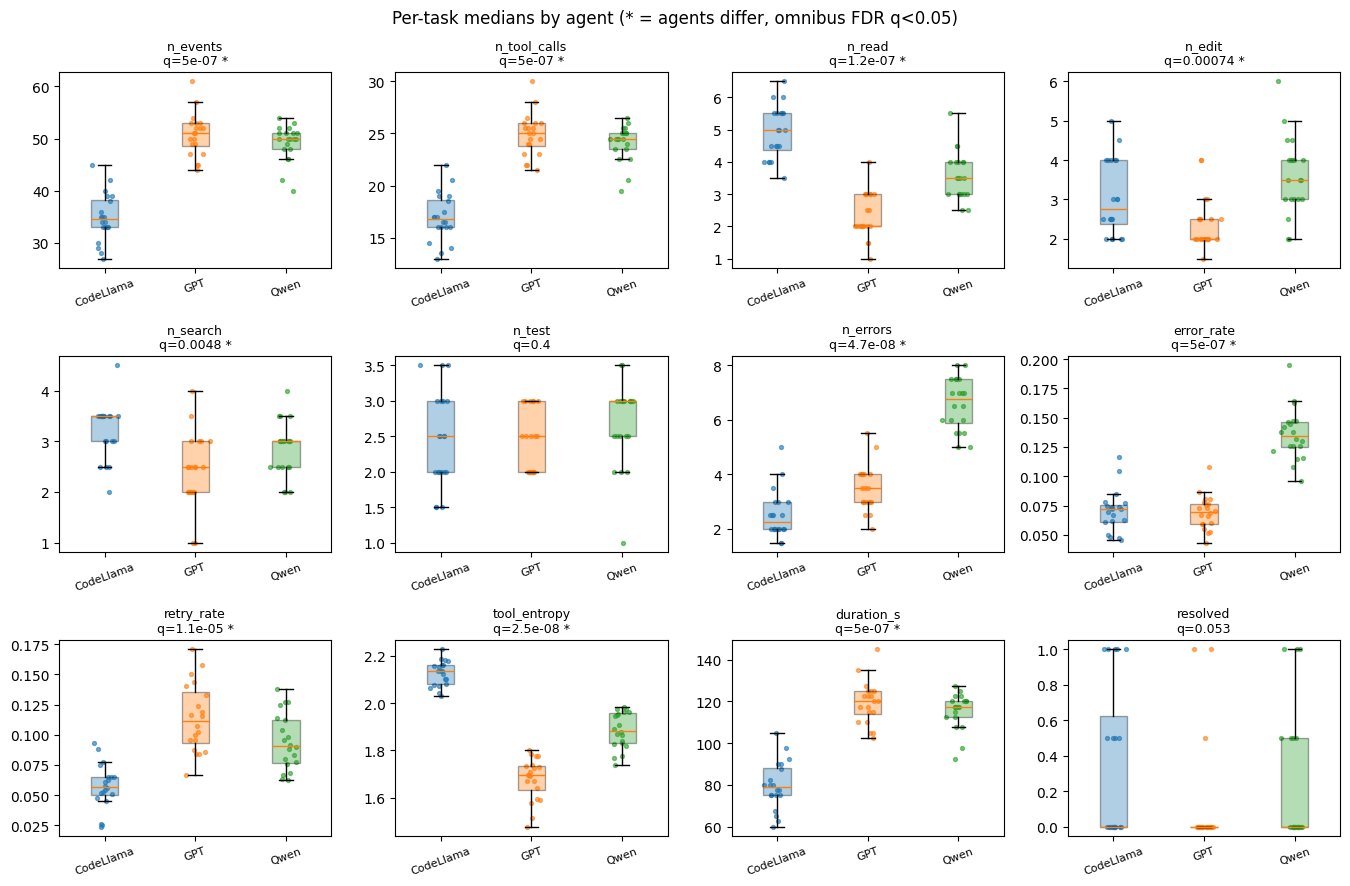

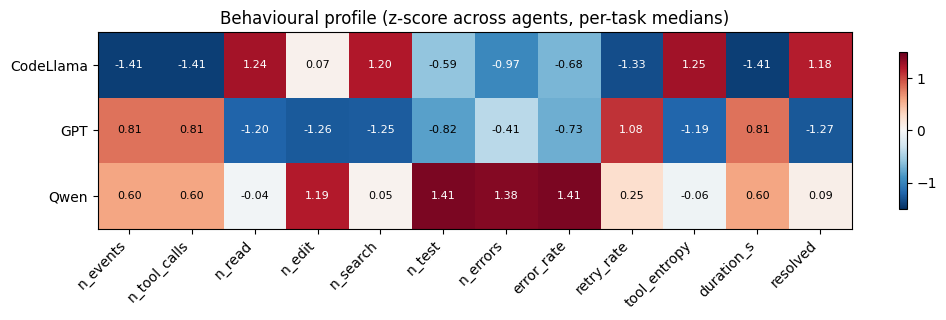

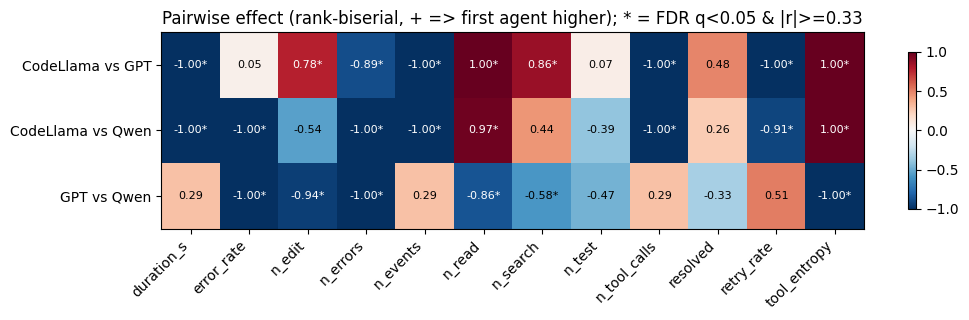

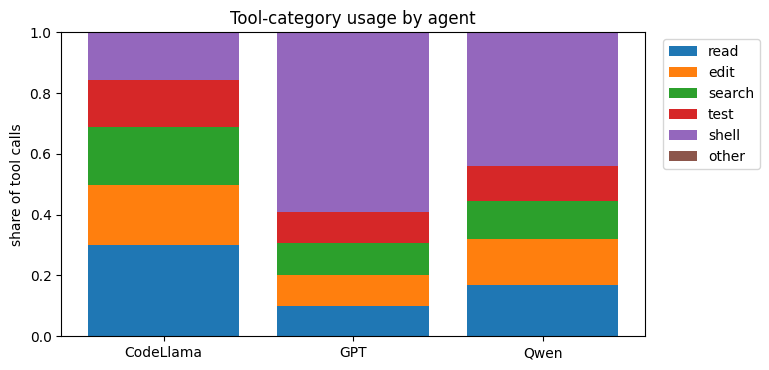

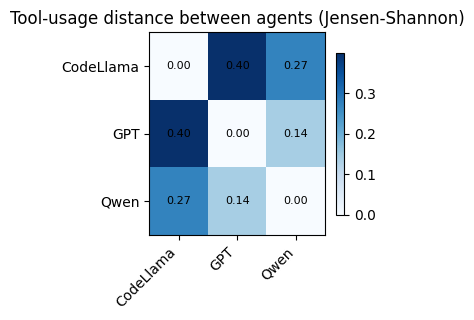

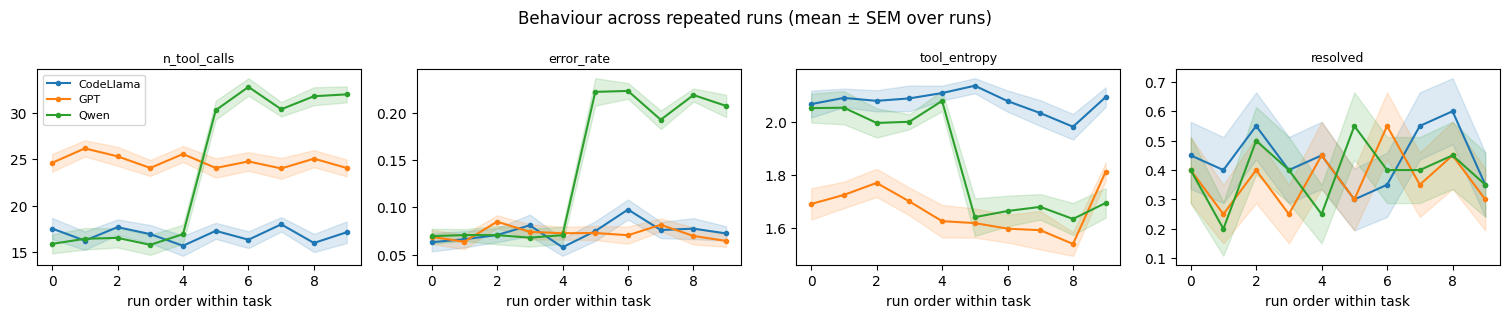

In [21]:
make_agent_plots(metrics, cmp, OUT / 'plots')

## Download results

In [22]:
import shutil
shutil.make_archive("drift_results", "zip", OUT)
try:
    from google.colab import files
    files.download("drift_results.zip")
except ImportError:
    print("Saved to drift_results.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>